Stitching in progress... this can take a moment with 4 high-res files.
Success! Displaying result:


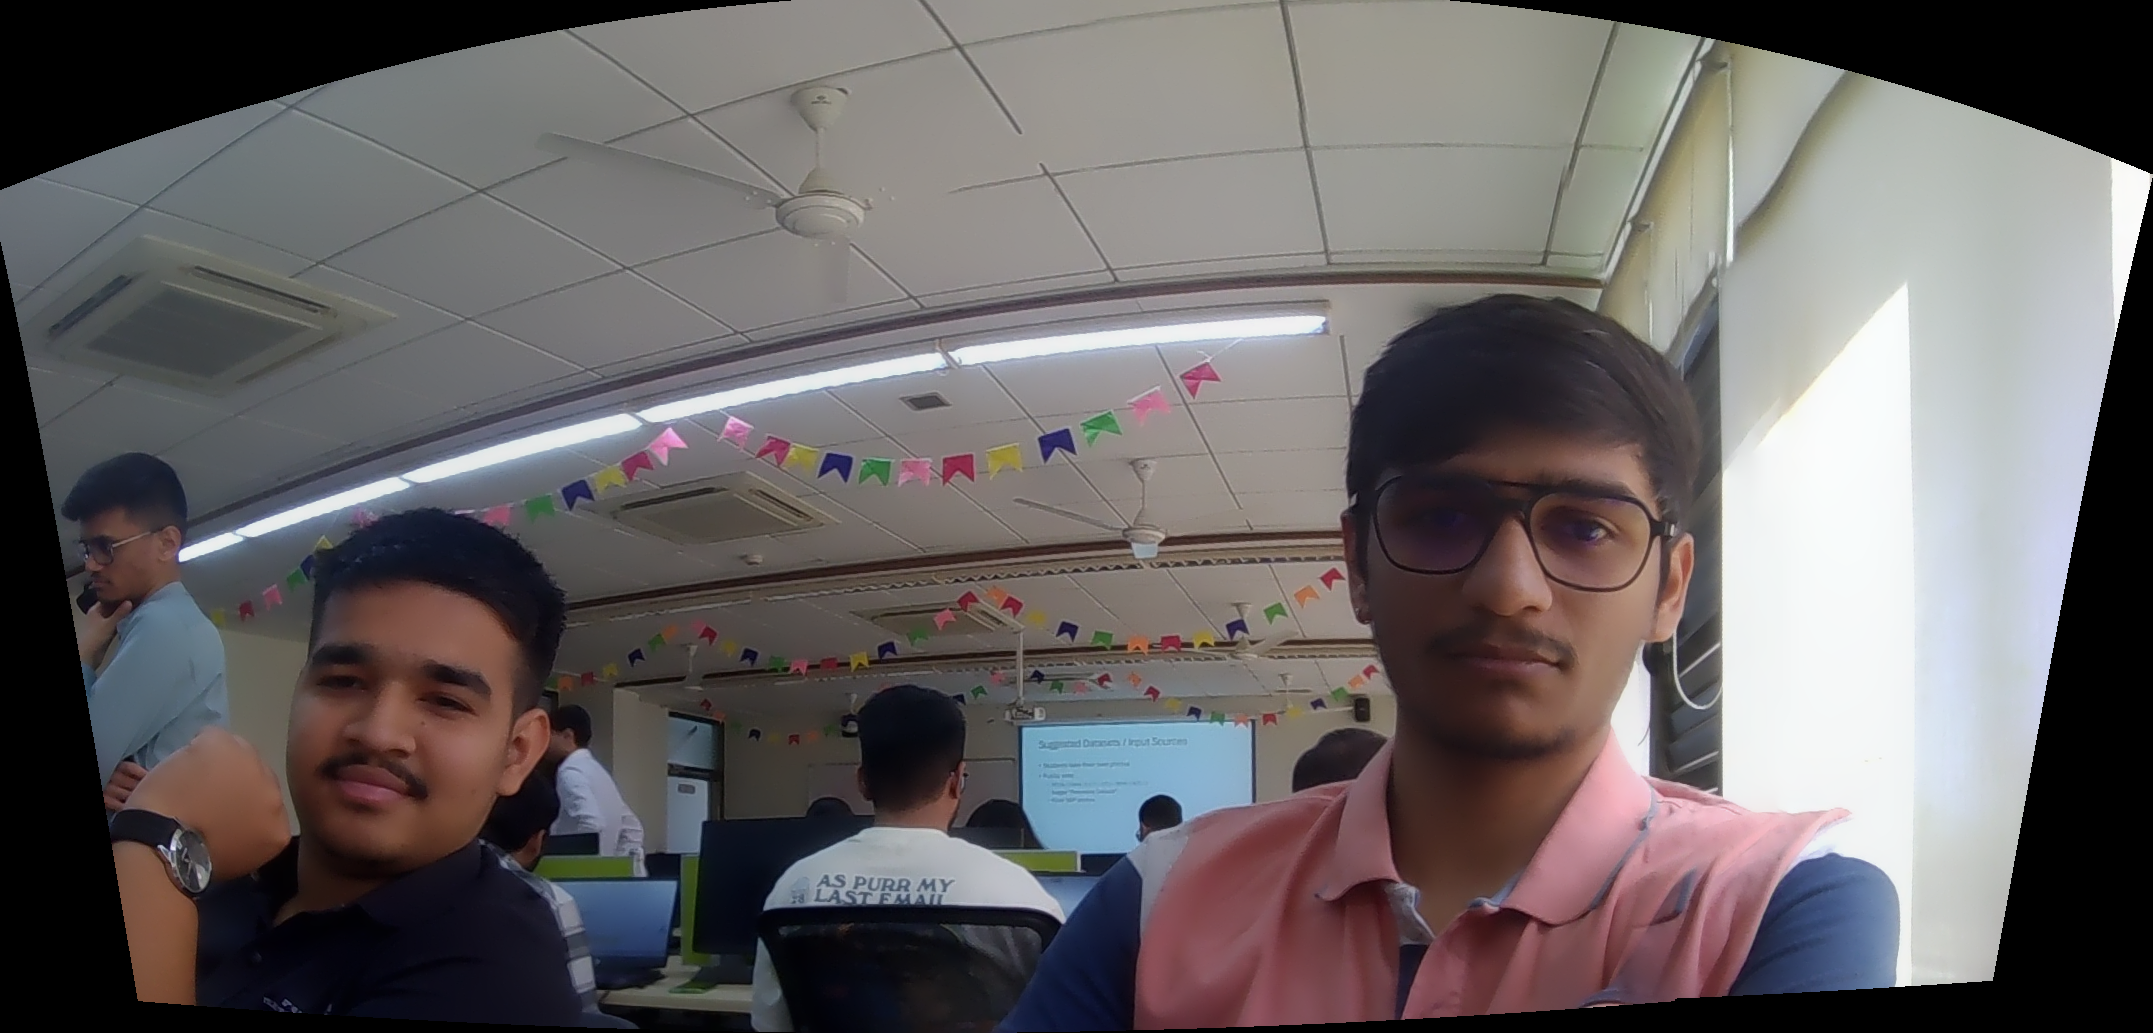

In [8]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # The fix for your error

def stitch_four_images(image_list):
    imgs = []

    # 1. Load the 4 images
    for img_path in image_list:
        img = cv2.imread(img_path)
        if img is None:
            print(f"Error: {img_path} not found. Check your file sidebar.")
            return
        imgs.append(img)

    # 2. Initialize the Stitcher
    # For PGDM level work, we use the PANORAMA mode (default)
    stitcher = cv2.Stitcher_create()

    print("Stitching in progress... this can take a moment with 4 high-res files.")
    status, result = stitcher.stitch(imgs)

    if status == cv2.Stitcher_OK:
        # 3. Optional: Basic Cropping to remove black borders
        # We create a 10px black border then find the contour of the actual image
        stitched = cv2.copyMakeBorder(result, 10, 10, 10, 10, cv2.BORDER_CONSTANT, (0,0,0))
        gray = cv2.cvtColor(stitched, cv2.COLOR_BGR2GRAY)
        thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)[1]

        cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
        if cnts:
            c = max(cnts, key=cv2.contourArea)
            (x, y, w, h) = cv2.boundingRect(c)
            result = result[y:y+h, x:x+w]

        # 4. Display and Save
        print("Success! Displaying result:")
        cv2_imshow(result) # Using the Colab patch
        cv2.imwrite('final_panorama.jpg', result)
    else:
        print(f"Stitching failed! Error Code: {status}")
        print("Tip: Ensure your images have at least 30% overlap and were taken from the same spot.")

# Run the function
files = ['1.jpg', '2.jpg', '3.jpg', '4.jpg']
stitch_four_images(files)